# ⚡ Electricity Consumption EDA
**Dataset:** Hourly electricity consumption for gas stations (~5M rows, 400+ stations, 1+ year)**

**Columns:**
- `EIC-код` — Station identifier (used for joining with dict)
- `Група` — Group
- `Дата` — Date
- `Year`, `Month`, `Day`, `Hour` — Time components
- `Sum of кВт` — Total electricity consumption (kWh)
- `Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год` — Avg distribution price (UAH excl. VAT per kWh)
- `Average of Ціна ЕЕ грн. без ПДВ/кВт*год` — Avg electricity price (UAH excl. VAT per kWh)

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
})
FIGSIZE_WIDE  = (16, 5)
FIGSIZE_TALL  = (14, 8)
FIGSIZE_SQ    = (10, 10)

# Short column aliases used throughout (set after loading)
COL_EIC   = 'EIC-код'
COL_GROUP = 'Група'
COL_DATE  = 'Дата'
COL_KWH   = 'Sum of кВт'
COL_DIST  = 'Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год'
COL_PRICE = 'Average of Ціна ЕЕ грн. без ПДВ/кВт*год'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data & Join with Dictionary

In [2]:
# ── Load dictionary (two sheets concatenated, deduped on EIC-код) ──────────
print('Loading dictionary...')
df1_dict = pd.read_excel('data/raw/full2024.xlsx', sheet_name='Dict')
df2_dict = pd.read_excel('data/raw/8month2025.xlsx', sheet_name='Dict')
dict_df = pd.concat([df1_dict, df2_dict])
dict_df.drop_duplicates(subset=[COL_EIC], inplace=True)
dict_df.reset_index(drop=True, inplace=True)

print(f'  Dictionary rows : {len(dict_df):,}')
print(f'  Dictionary cols : {dict_df.columns.tolist()}')
dict_df.head(3)

Loading dictionary...
  Dictionary rows : 429
  Dictionary cols : ['EIC-код', 'Унікод', 'АЗС', 'Тип', 'Область', 'Адреса', 'GPS-координати - Широта', 'GPS-координати - Довгота', 'ОСР код', 'ОСР опис']


,EIC-код,Унікод,АЗС,Тип,Область,Адреса,GPS-координати - Широта,GPS-координати - Довгота,ОСР код,ОСР опис
0,62Z3386096691495,40110200,АЗС_02,ОККО-міська,Львівська,"м. Львів, вул. Замарстинівська, 174",49.871014,24.020029,MGA-00900,Львів
1,62Z5700239654314,40110500,АЗС_05,ОККО-міська,Львівська,"м. Львів, вул. Клепарівська, 30 Б",49.853477,24.014784,MGA-00900,Львів
2,62Z8292498523912,40110700,АЗС_07,ОККО-міська,Львівська,"м. Львів, вул. Володимира Великого, 58",49.812439,23.984974,MGA-00900,Львів


In [3]:
# ── Load main data ─────────────────────────────────────────────────────────
# Adjust sheet_name / path as needed
print('Loading main dataset (may take a moment for ~5M rows)...')
df = pd.read_parquet(
    '../data/raw/full2024_8month2025.parquet'
)
print(f'  Main dataset rows before dropping nans: {len(df):,}')
df.dropna(inplace=True)

cols_to_int = ['Year', 'Month', 'Day', 'Hour']
for col in cols_to_int:
    df[col] = df[col].astype(int)

print(f'  Main data rows  : {len(df):,}')
print(f'  Main data cols  : {df.columns.tolist()}')

Loading main dataset (may take a moment for ~5M rows)...
  Main dataset rows before dropping nans: 5,454,729
  Main data rows  : 5,454,713
  Main data cols  : ['EIC-код', 'Група', 'Дата', 'Year', 'Month', 'Day', 'Hour', 'Sum of кВт', 'Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год', 'Average of Ціна ЕЕ грн. без ПДВ/кВт*год', '__source_file']


In [4]:
# ── Left-join main data with dictionary on EIC-код ─────────────────────────
df = df.merge(dict_df, on=COL_EIC, how='left', suffixes=('', '_dict'))

print(f'Post-join shape : {df.shape}')
print(f'Unmatched EICs  : {df[dict_df.columns.drop(COL_EIC)[0]].isna().sum():,}'  # first dict col as proxy
      if len(dict_df.columns) > 1 else 'N/A')
df.head(3)

Post-join shape : (5454713, 20)
Unmatched EICs  : 0


,EIC-код,Група,Дата,Year,Month,Day,Hour,Sum of кВт,Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год,Average of Ціна ЕЕ грн. без ПДВ/кВт*год,__source_file,Унікод,АЗС,Тип,Область,Адреса,GPS-координати - Широта,GPS-координати - Довгота,ОСР код,ОСР опис
0,62Z0008583037334,Б,2024-12-01,2024,12,1,1,20.716983,2.15221,6.13675,12_2024.xlsx,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.44243,22.19219,MGA-00700,Ужгород
1,62Z0008583037334,Б,2024-12-01,2024,12,1,2,19.365875,2.15221,6.13675,12_2024.xlsx,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.44243,22.19219,MGA-00700,Ужгород
2,62Z0008583037334,Б,2024-12-01,2024,12,1,3,18.529475,2.15221,6.13675,12_2024.xlsx,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.44243,22.19219,MGA-00700,Ужгород


In [50]:
# ── Parse / validate datetime ──────────────────────────────────────────────
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce')

# Build a proper datetime with hour
df['datetime'] = df[COL_DATE] + pd.to_timedelta(df['Hour'].fillna(0), unit='h')

# Convenience columns
df['week']    = df['datetime'].dt.isocalendar().week.astype('Int16')
df['weekday'] = df['datetime'].dt.dayofweek          # 0=Mon … 6=Sun
df['weekday_name'] = df['datetime'].dt.day_name()
df['is_weekend']   = df['weekday'] >= 5
df['quarter']      = df['datetime'].dt.quarter

print('Datetime columns created ✓')
print(f'Date range: {df[COL_DATE].min().date()} → {df[COL_DATE].max().date()}')

Datetime columns created ✓
Date range: 2024-01-01 → 2025-08-31


## 2. Dataset Overview

In [51]:
# Basic shape & types
print('=== Shape ===')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : {df.shape[1]}')
print()
print('=== dtypes ===')
print(df.dtypes)

=== Shape ===
  Rows    : 5,454,713
  Columns : 26

=== dtypes ===
EIC-код                                                      object
Група                                                string[python]
Дата                                                 datetime64[ns]
Year                                                          int64
Month                                                         int64
Day                                                           int64
Hour                                                          int64
Sum of кВт                                                  float64
Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год           float64
Average of Ціна ЕЕ грн. без ПДВ/кВт*год                     float64
__source_file                                        string[python]
Унікод                                                        int64
АЗС                                                          object
Тип                                              

In [52]:
# Coverage stats
n_stations  = df[COL_EIC].nunique()
n_groups    = df[COL_GROUP].nunique()
date_range  = (df[COL_DATE].max() - df[COL_DATE].min()).days
total_kwh   = df[COL_KWH].sum()

print(f'Unique stations  : {n_stations:,}')
print(f'Unique groups    : {n_groups:,}')
print(f'Date range       : {date_range:,} days')
print(f'Total kWh        : {total_kwh:,.0f}')
print(f'Avg kWh/row      : {df[COL_KWH].mean():.2f}')

Unique stations  : 411
Unique groups    : 2
Date range       : 608 days
Total kWh        : 93,608,624
Avg kWh/row      : 17.16


In [53]:
# .describe() for numeric cols
num_cols = [COL_KWH, COL_DIST, COL_PRICE]
df[num_cols].describe().round(4)

,Sum of кВт,Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год,Average of Ціна ЕЕ грн. без ПДВ/кВт*год
count,5.454713e+06,5.454713e+06,5.454713e+06
mean,1.716110e+01,1.784800e+00,5.053500e+00
std,1.468610e+01,3.698000e-01,9.515000e-01
min,-1.518510e+01,0.000000e+00,3.109200e+00
25%,9.508000e+00,1.631000e+00,4.715300e+00
50%,1.408520e+01,1.763400e+00,5.441000e+00
75%,1.987470e+01,2.028200e+00,5.721700e+00
max,1.311500e+03,2.811100e+00,6.171900e+00


## 3. Missing Value Analysis

In [54]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

print(f'Columns with missing values: {len(missing_df)}')
display(missing_df)

Columns with missing values: 0


,missing_count,missing_%


In [55]:
# Visual: missing % per column
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_df) * 0.5)))
    missing_df['missing_%'].sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Missing Data (%) by Column', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing %')
    ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('✓ No missing values found.')

✓ No missing values found.


## 4. Distributions

In [56]:
# ── Sample for heavy plots (2M+ rows slow down rendering) ──────────────────
SAMPLE_N = 20_000_000
df_sample = df.sample(min(SAMPLE_N, len(df)), random_state=42)
print(f'Using {len(df_sample):,} rows for distribution plots')

Using 5,454,713 rows for distribution plots


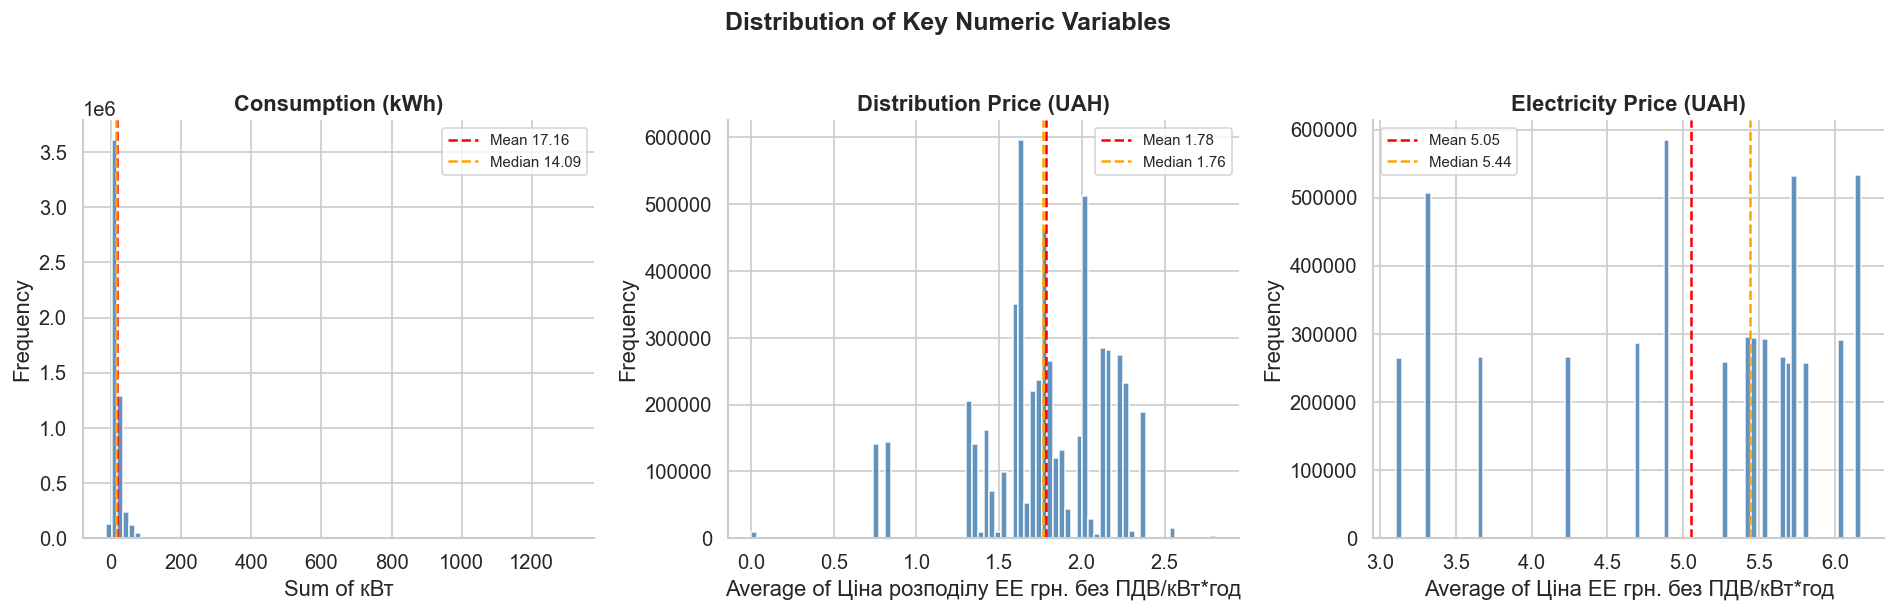

In [57]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
titles = ['Consumption (kWh)', 'Distribution Price (UAH)', 'Electricity Price (UAH)']

for ax, col, title in zip(axes, num_cols, titles):
    data = df_sample[col].dropna()
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', label=f'Mean {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Median {data.median():.2f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Key Numeric Variables', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

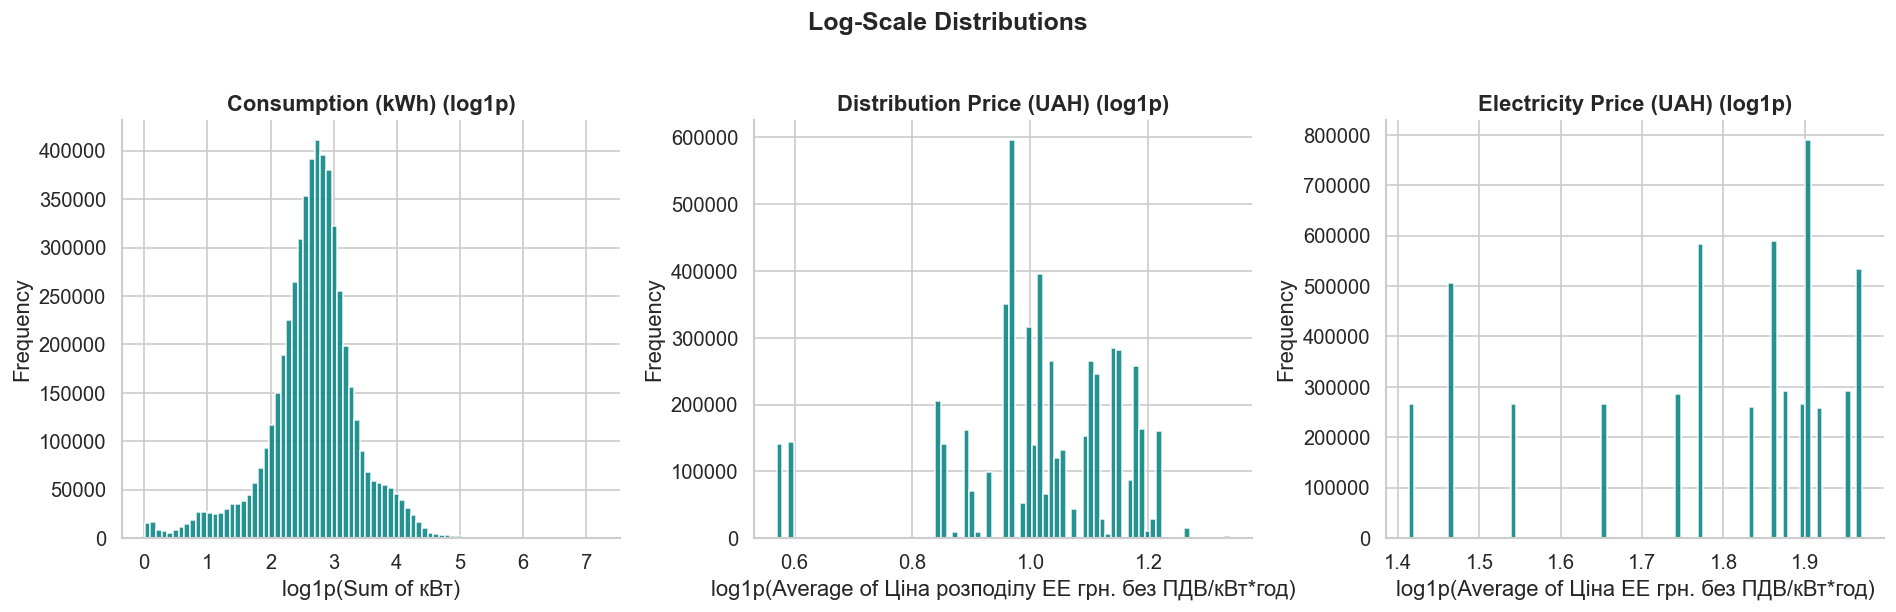

In [58]:
# Log-scale distributions (useful for right-skewed data)
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)

for ax, col, title in zip(axes, num_cols, titles):
    data = df_sample[col].dropna()
    data_pos = data[data > 0]
    ax.hist(np.log1p(data_pos), bins=80, color='teal', edgecolor='white', alpha=0.85)
    ax.set_title(f'{title} (log1p)', fontweight='bold')
    ax.set_xlabel(f'log1p({col})')
    ax.set_ylabel('Frequency')

plt.suptitle('Log-Scale Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

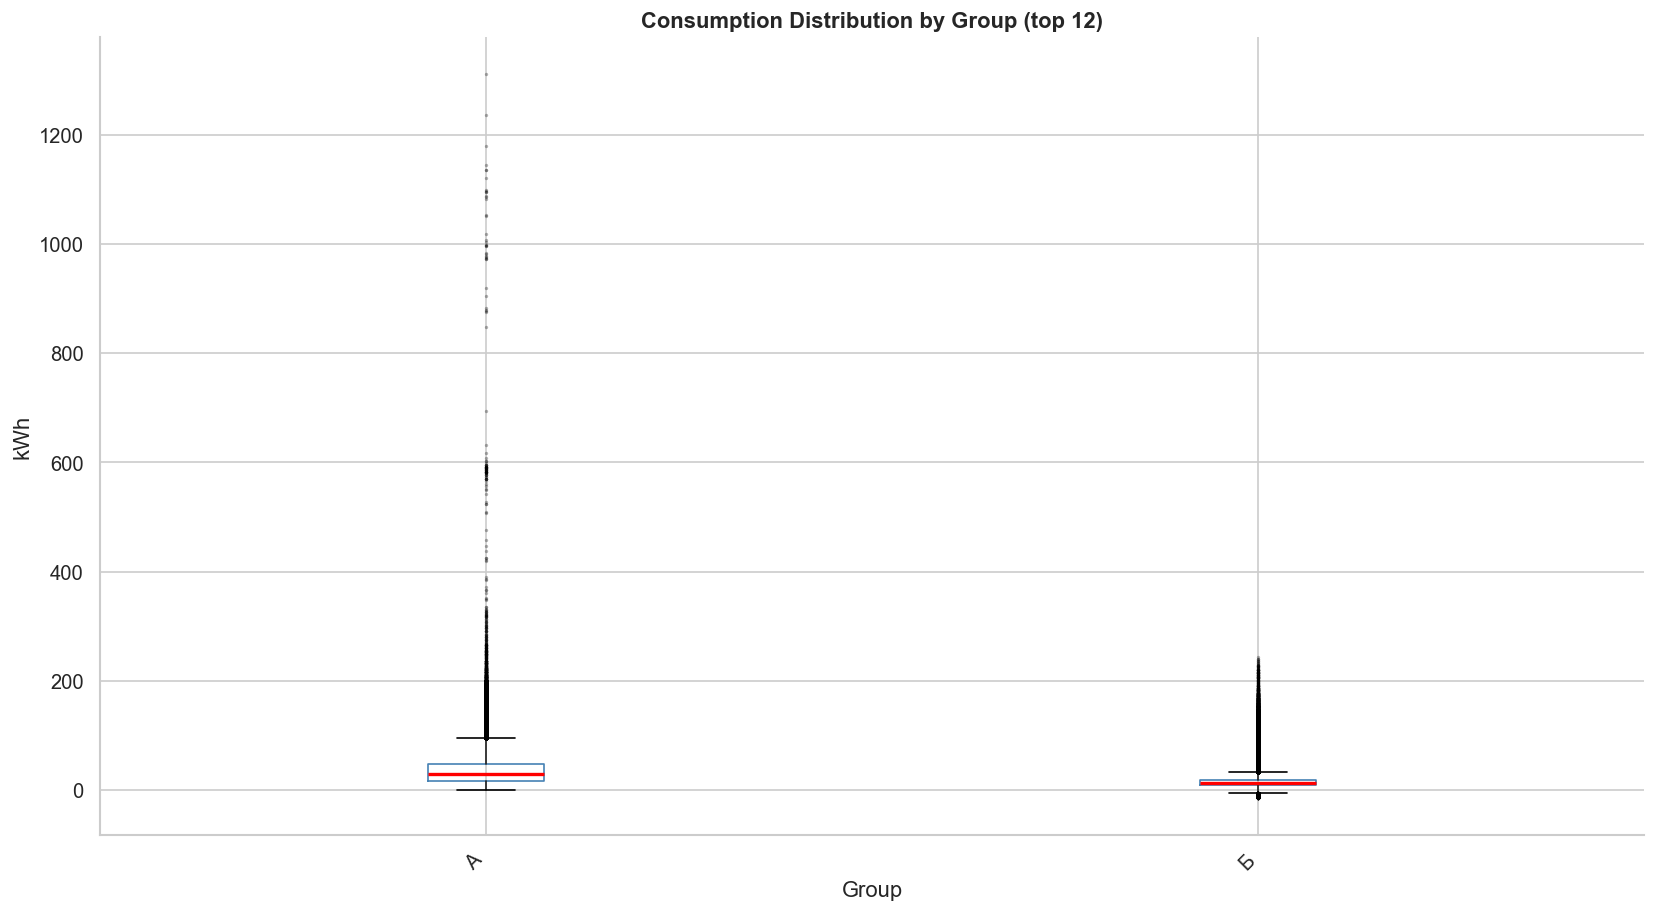

In [59]:
# Box-plots by Group
top_groups = df[COL_GROUP].value_counts().head(12).index
df_top = df[df[COL_GROUP].isin(top_groups)]

fig, ax = plt.subplots(figsize=FIGSIZE_TALL)
df_top.boxplot(column=COL_KWH, by=COL_GROUP, ax=ax, notch=False,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('Consumption Distribution by Group (top 12)', fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Group')
ax.set_ylabel('kWh')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Temporal Analysis

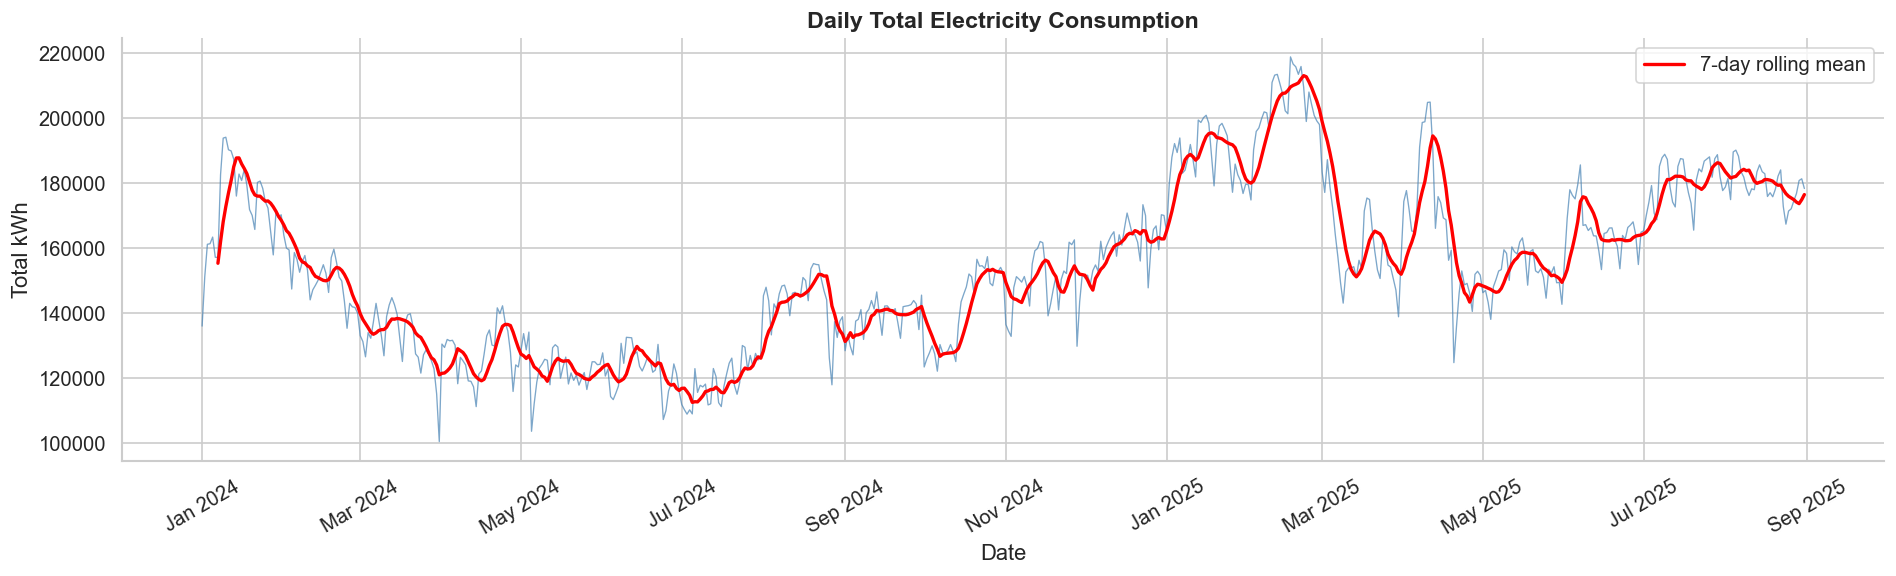

In [60]:
# ── Daily total consumption ────────────────────────────────────────────────
daily = df.groupby(COL_DATE)[COL_KWH].sum().reset_index()
daily.columns = ['date', 'total_kwh']

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(daily['date'], daily['total_kwh'], linewidth=0.8, color='steelblue', alpha=0.7)
ax.plot(daily['date'], daily['total_kwh'].rolling(7).mean(), color='red',
        linewidth=2, label='7-day rolling mean')
ax.set_title('Daily Total Electricity Consumption', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

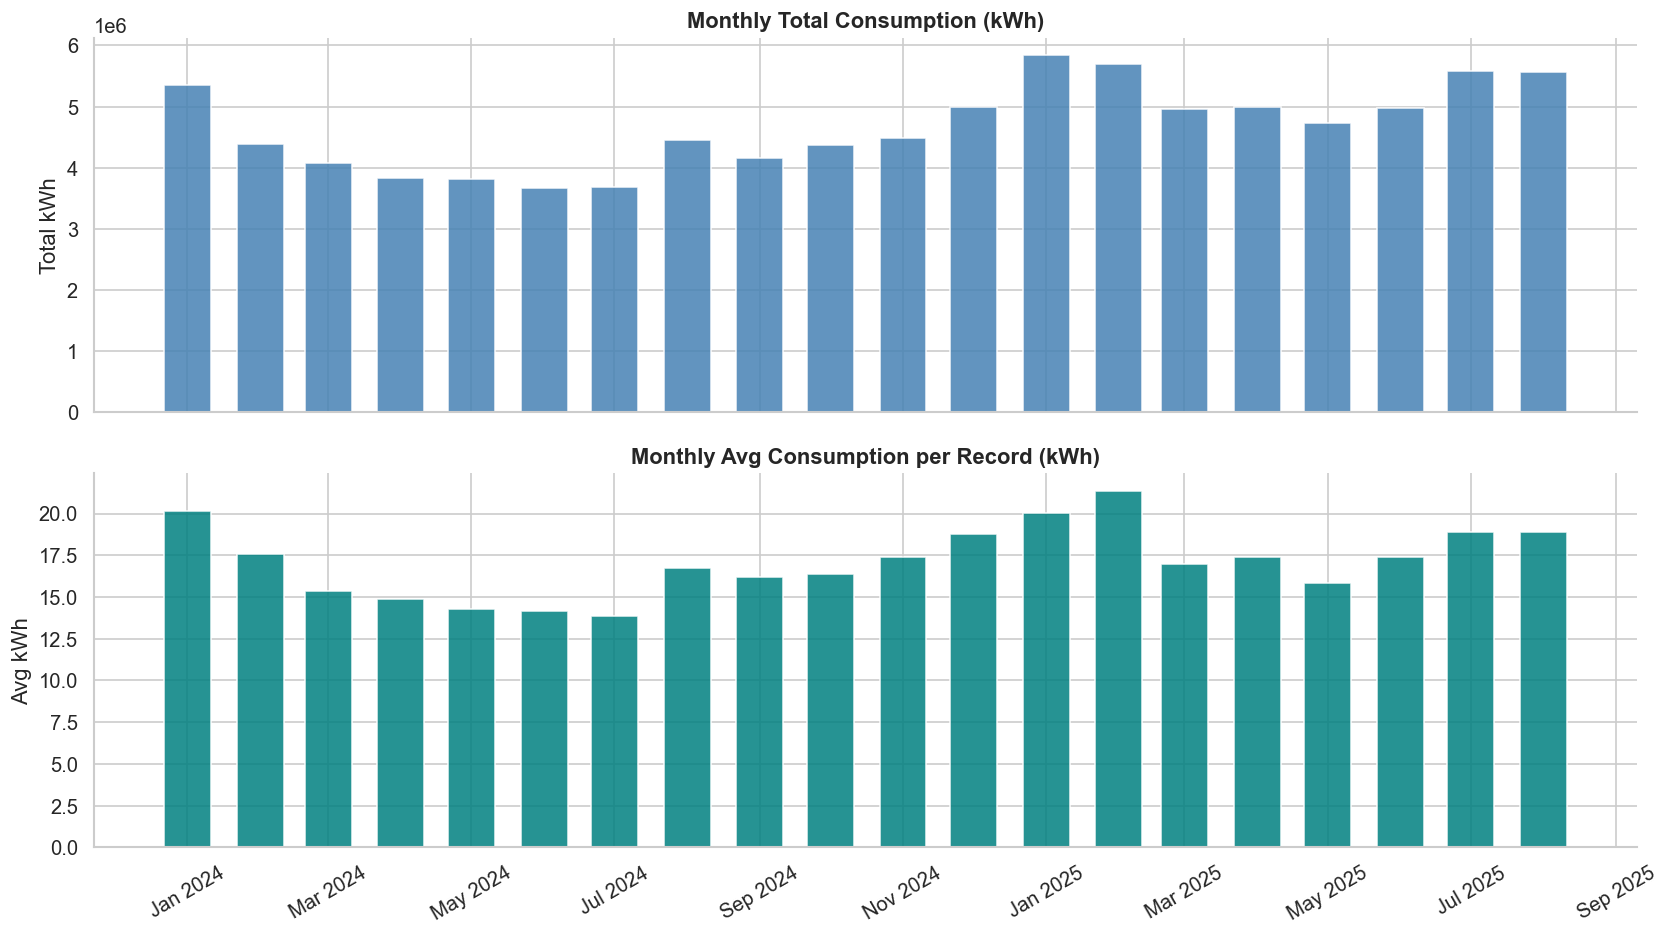

In [61]:
# ── Monthly aggregation ────────────────────────────────────────────────────
monthly = df.groupby(['Year', 'Month'])[COL_KWH].agg(['sum', 'mean', 'count']).reset_index()
monthly['period'] = pd.to_datetime(
    monthly['Year'].astype(int).astype(str) + '-' + monthly['Month'].astype(int).astype(str).str.zfill(2)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(monthly['period'], monthly['sum'], width=20, color='steelblue', alpha=0.85)
axes[0].set_title('Monthly Total Consumption (kWh)', fontweight='bold')
axes[0].set_ylabel('Total kWh')

axes[1].bar(monthly['period'], monthly['mean'], width=20, color='teal', alpha=0.85)
axes[1].set_title('Monthly Avg Consumption per Record (kWh)', fontweight='bold')
axes[1].set_ylabel('Avg kWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

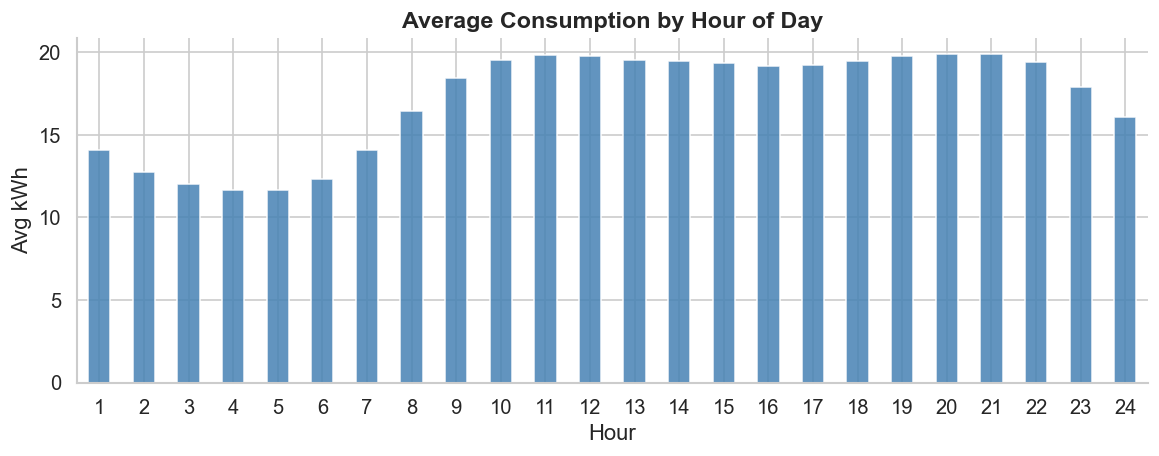

In [62]:
# ── Hourly profile ─────────────────────────────────────────────────────────
hourly_avg = df.groupby('Hour')[COL_KWH].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_avg.plot.bar(ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Average Consumption by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg kWh')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

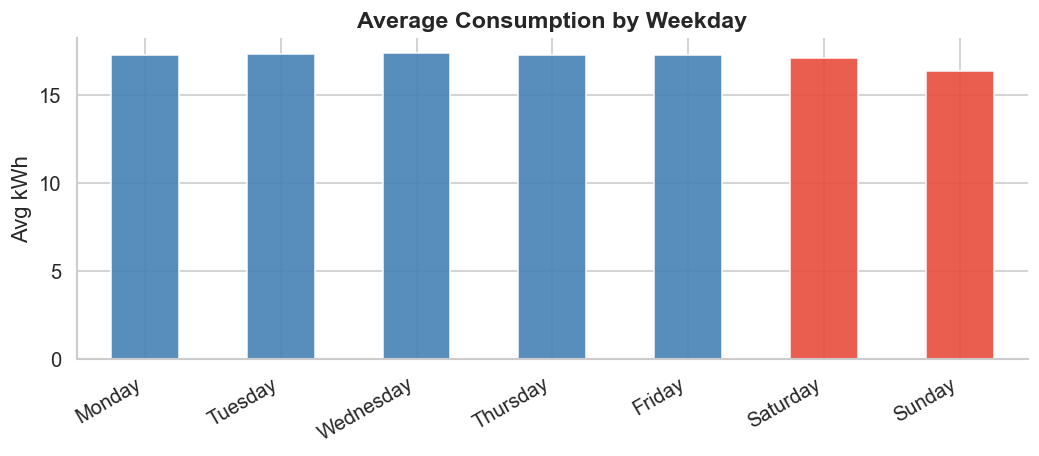

In [63]:
# ── Weekday profile ────────────────────────────────────────────────────────
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_avg = df.groupby('weekday_name')[COL_KWH].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if d in ['Saturday','Sunday'] else 'steelblue' for d in weekday_order]
weekday_avg.plot.bar(ax=ax, color=colors, edgecolor='white', alpha=0.9)
ax.set_title('Average Consumption by Weekday', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Avg kWh')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

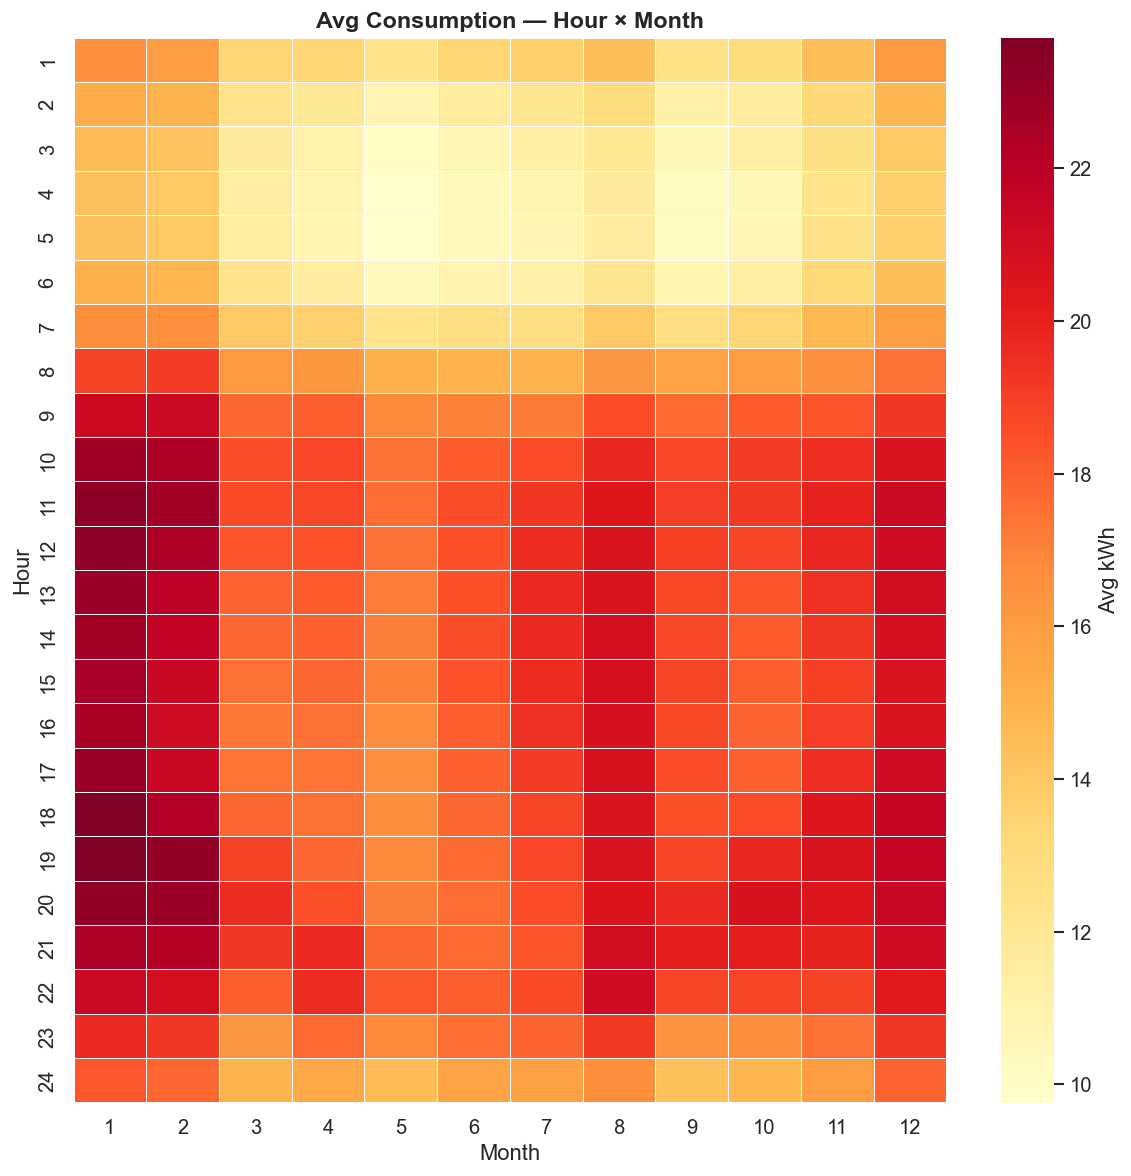

In [64]:
# ── Heatmap: Hour × Month ──────────────────────────────────────────────────
pivot_hm = df.pivot_table(values=COL_KWH, index='Hour', columns='Month', aggfunc='mean')

fig, ax = plt.subplots(figsize=FIGSIZE_SQ)
sns.heatmap(pivot_hm, cmap='YlOrRd', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Avg kWh'}, ax=ax)
ax.set_title('Avg Consumption — Hour × Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Hour')
plt.tight_layout()
plt.show()

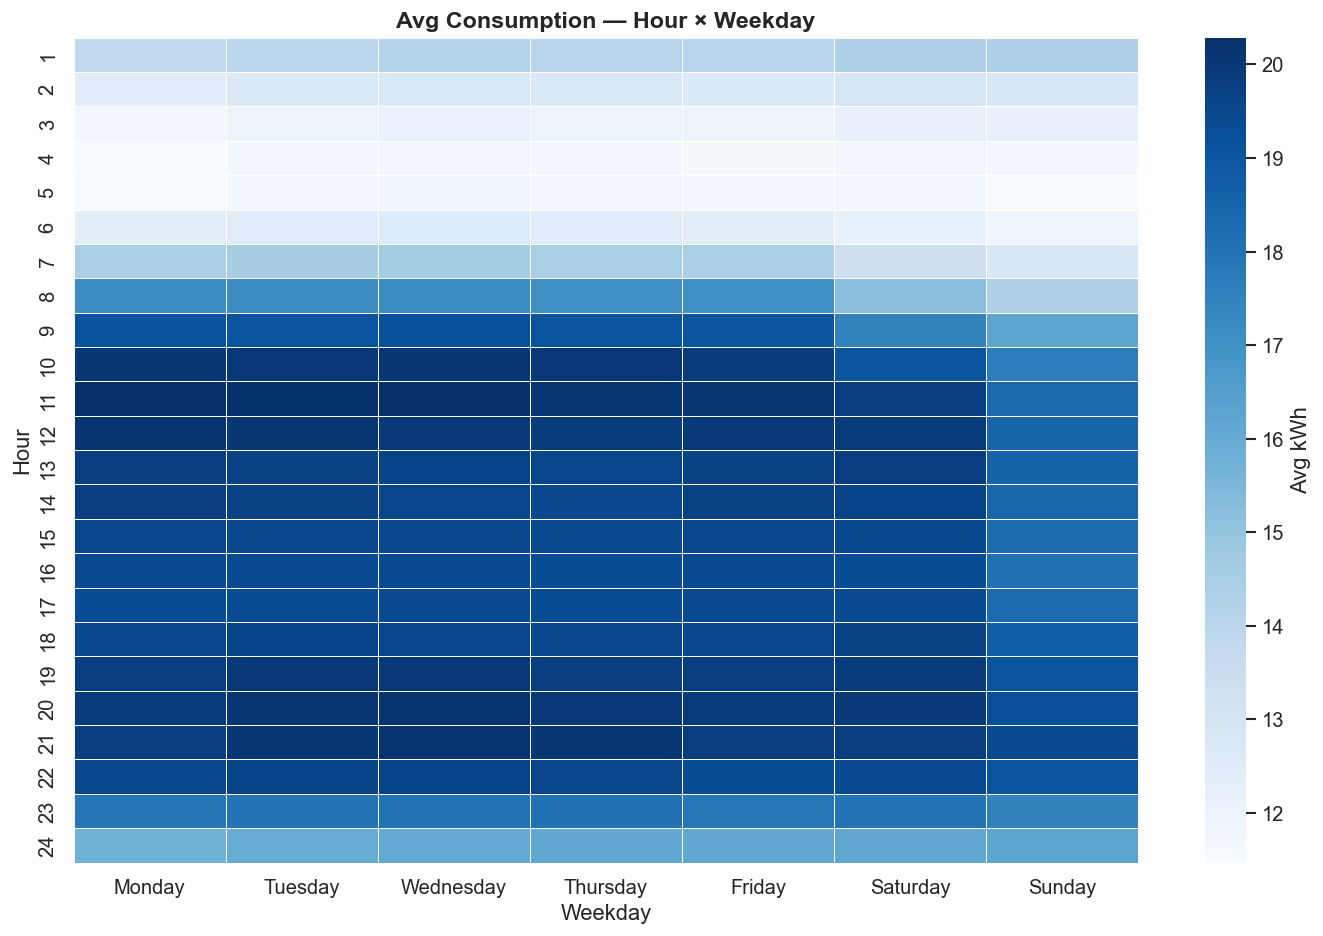

In [65]:
# ── Heatmap: Hour × Weekday ────────────────────────────────────────────────
pivot_hw = df.pivot_table(values=COL_KWH, index='Hour', columns='weekday', aggfunc='mean')
pivot_hw.columns = [weekday_order[i] for i in pivot_hw.columns]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_hw, cmap='Blues', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Avg kWh'}, ax=ax)
ax.set_title('Avg Consumption — Hour × Weekday', fontsize=14, fontweight='bold')
ax.set_xlabel('Weekday')
ax.set_ylabel('Hour')
plt.tight_layout()
plt.show()

## 6. Station-Level Analysis

In [66]:
# Per-station aggregation
station_agg = df.groupby(COL_EIC).agg(
    total_kwh   = (COL_KWH, 'sum'),
    mean_kwh    = (COL_KWH, 'mean'),
    median_kwh  = (COL_KWH, 'median'),
    std_kwh     = (COL_KWH, 'std'),
    n_records   = (COL_KWH, 'count'),
    mean_price  = (COL_PRICE, 'mean'),
    mean_dist   = (COL_DIST, 'mean'),
).reset_index()

station_agg['cv'] = station_agg['std_kwh'] / station_agg['mean_kwh']  # coefficient of variation
print(f'Station aggregation: {station_agg.shape}')
station_agg.describe().round(3)

Station aggregation: (411, 9)


,total_kwh,mean_kwh,median_kwh,std_kwh,n_records,mean_price,mean_dist,cv
count,411.000,411.000,411.000,411.000,411.000,411.000,411.000,411.000
mean,227758.209,17.430,17.082,5.708,13271.808,5.069,1.777,0.334
std,170975.184,13.128,12.836,6.286,3231.836,0.176,0.369,0.152
min,1176.000,0.080,0.076,0.028,744.000,3.503,0.784,0.091
25%,140282.500,11.326,11.238,3.367,14614.000,5.040,1.644,0.259
50%,198276.000,14.642,14.497,4.416,14614.000,5.040,1.752,0.291
75%,250086.500,19.084,18.570,5.840,14614.000,5.040,2.112,0.349
max,1314354.000,115.372,115.351,77.028,14614.000,6.100,2.374,1.494


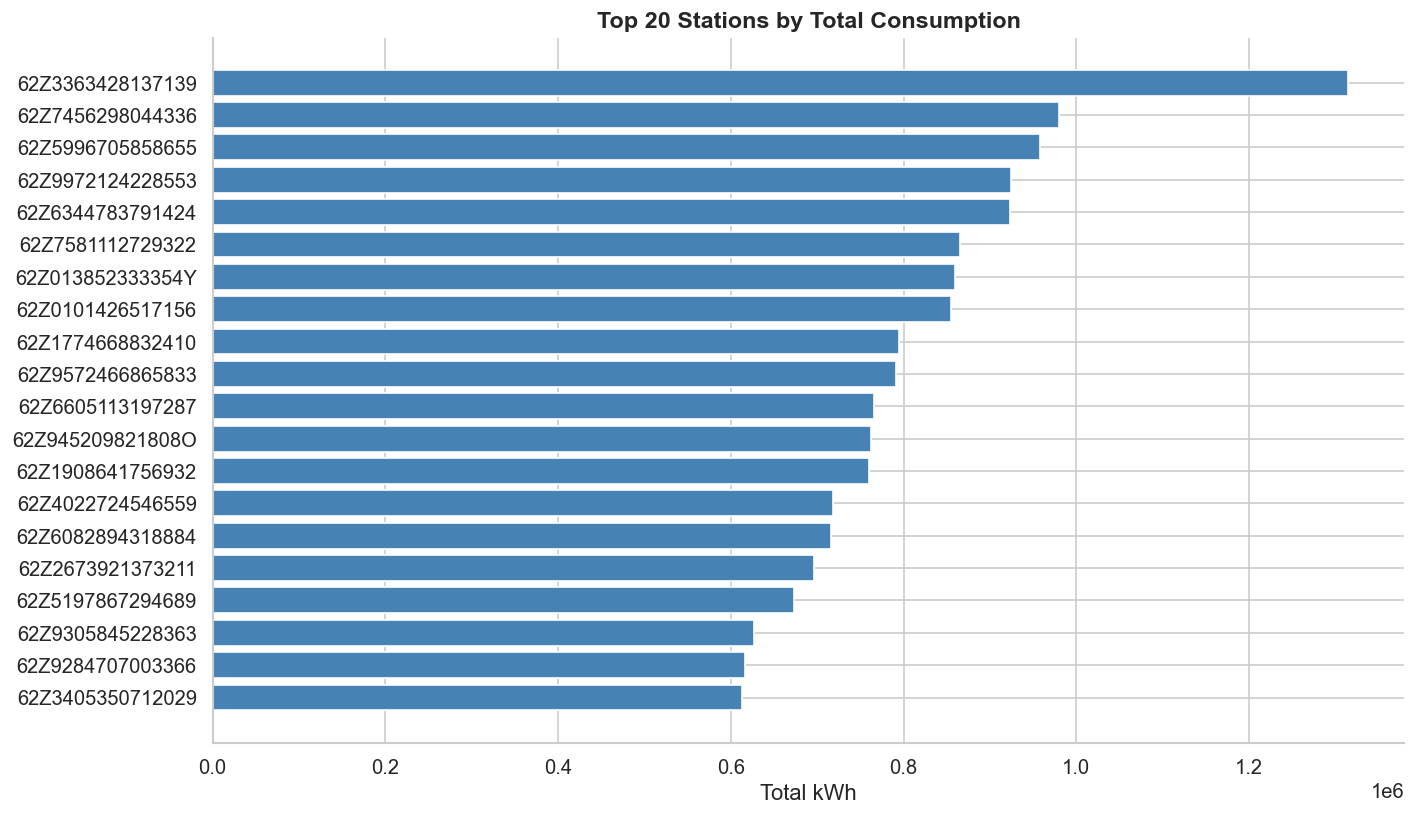

In [67]:
# Top 20 highest-consumption stations
top20 = station_agg.nlargest(20, 'total_kwh')

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top20[COL_EIC].astype(str), top20['total_kwh'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Stations by Total Consumption', fontsize=14, fontweight='bold')
ax.set_xlabel('Total kWh')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

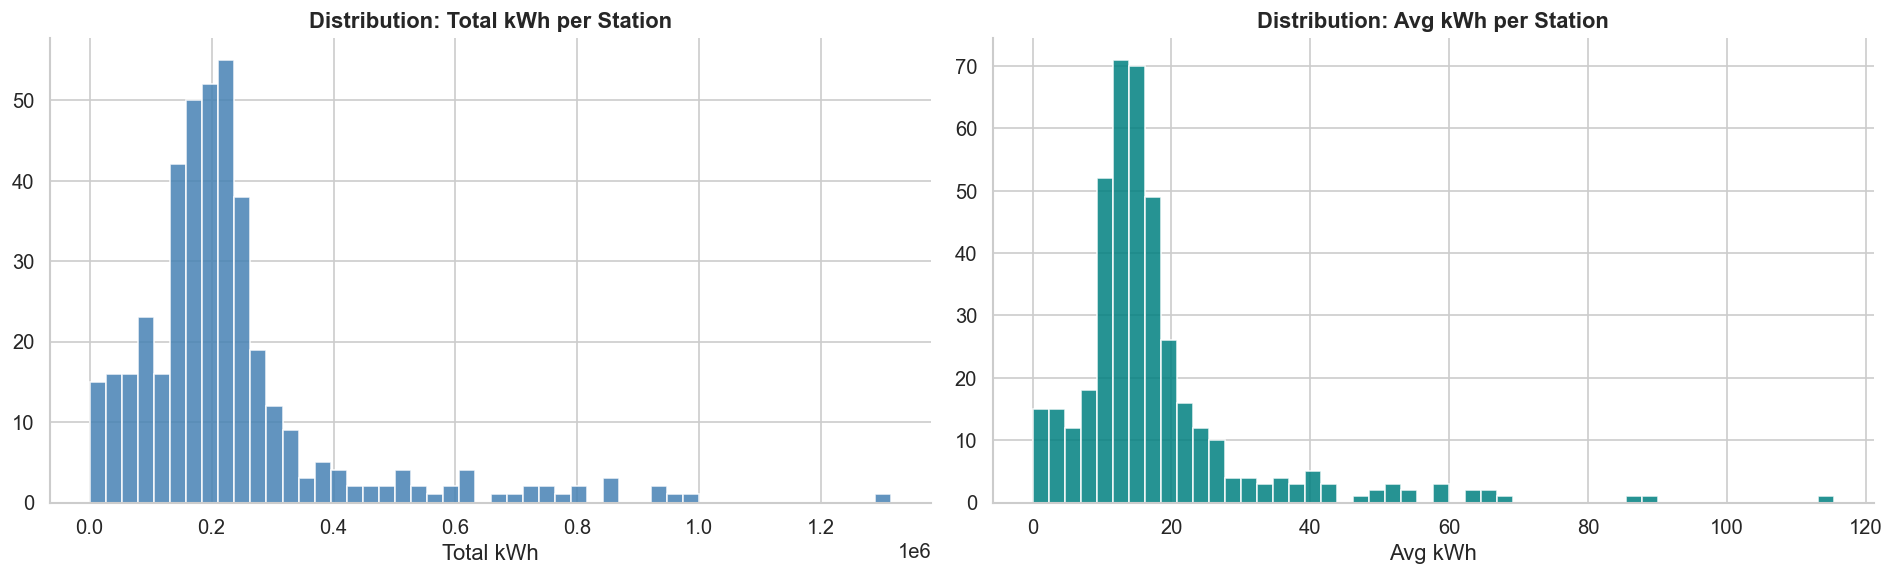

In [68]:
# Distribution of total consumption across stations
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

axes[0].hist(station_agg['total_kwh'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution: Total kWh per Station', fontweight='bold')
axes[0].set_xlabel('Total kWh')

axes[1].hist(station_agg['mean_kwh'], bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution: Avg kWh per Station', fontweight='bold')
axes[1].set_xlabel('Avg kWh')

plt.tight_layout()
plt.show()

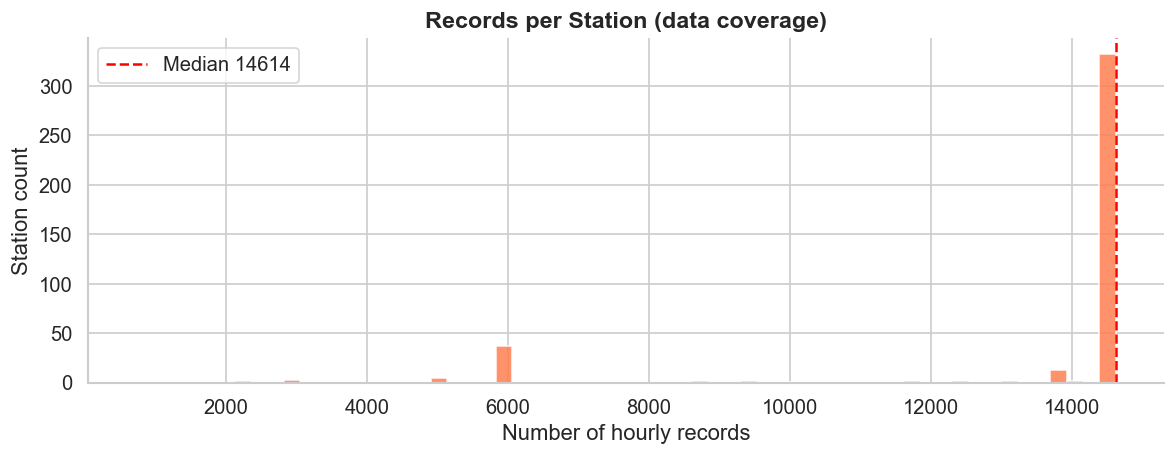

In [69]:
# Station coverage (record count per station)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(station_agg['n_records'], bins=60, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(station_agg['n_records'].median(), color='red', linestyle='--',
           label=f'Median {station_agg["n_records"].median():.0f}')
ax.set_title('Records per Station (data coverage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of hourly records')
ax.set_ylabel('Station count')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Group-Level Analysis

In [70]:
group_agg = df.groupby(COL_GROUP).agg(
    total_kwh  = (COL_KWH, 'sum'),
    mean_kwh   = (COL_KWH, 'mean'),
    n_stations = (COL_EIC, 'nunique'),
    n_records  = (COL_KWH, 'count'),
    mean_price = (COL_PRICE, 'mean'),
).reset_index().sort_values('total_kwh', ascending=False)

group_agg.head(15)

,Група,total_kwh,mean_kwh,n_stations,n_records,mean_price
1,Б,81129370.0,15.863898,399,5114088,5.036596
0,А,12479254.0,36.636342,52,340625,5.306719


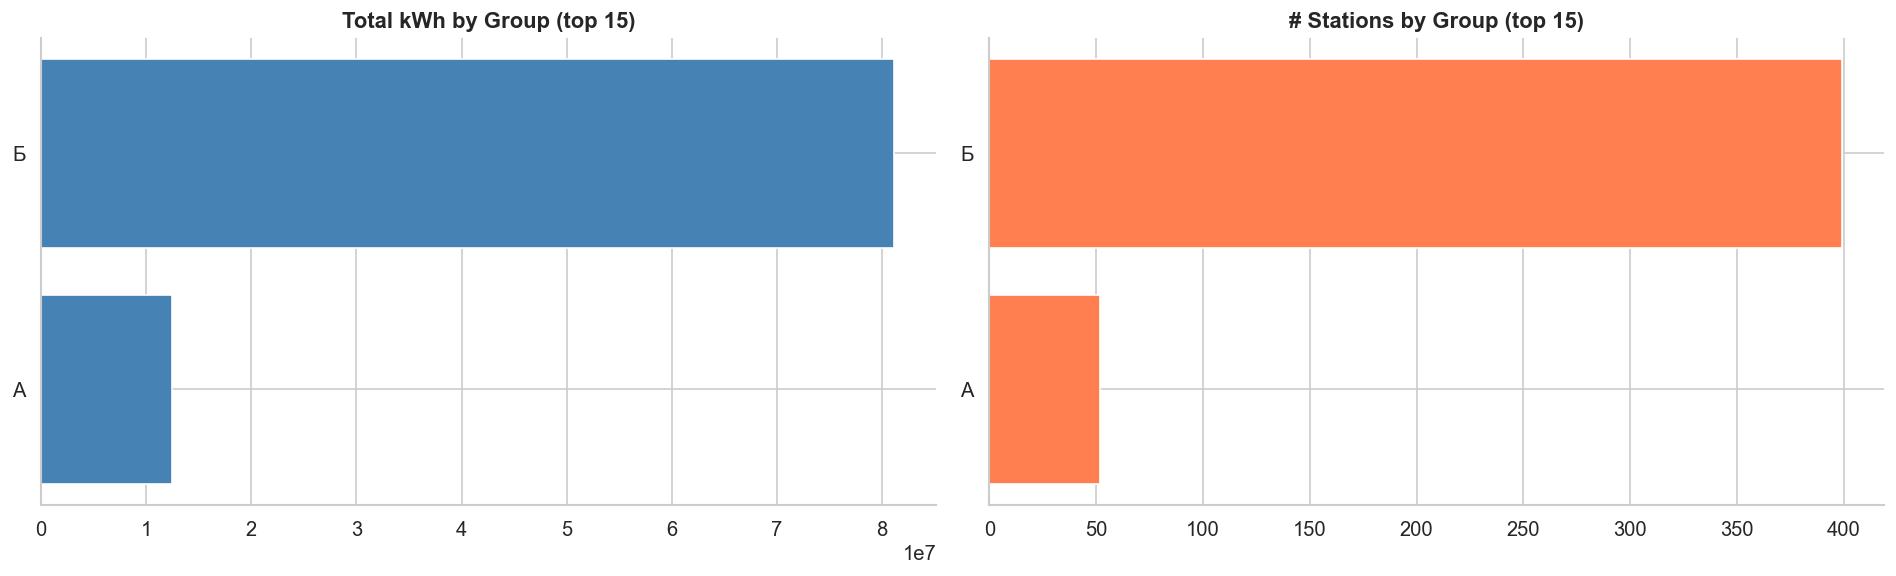

In [71]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

top_g = group_agg.head(15)

axes[0].barh(top_g[COL_GROUP].astype(str), top_g['total_kwh'], color='steelblue', edgecolor='white')
axes[0].set_title('Total kWh by Group (top 15)', fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(top_g[COL_GROUP].astype(str), top_g['n_stations'], color='coral', edgecolor='white')
axes[1].set_title('# Stations by Group (top 15)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

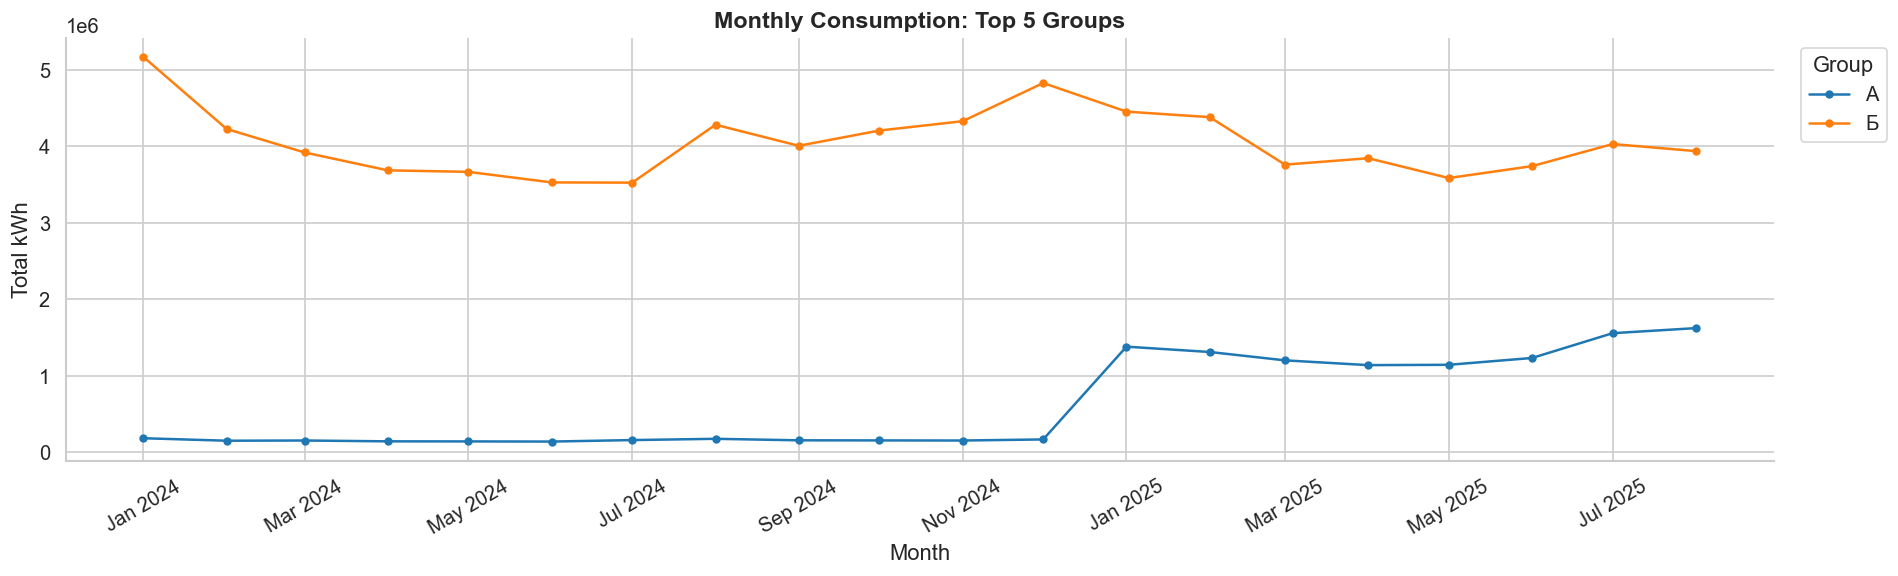

In [72]:
# Monthly trend per top-5 groups
top5_groups = group_agg.head(5)[COL_GROUP].tolist()
df_t5 = df[df[COL_GROUP].isin(top5_groups)]

monthly_group = df_t5.groupby([COL_GROUP, 'Year', 'Month'])[COL_KWH].sum().reset_index()
monthly_group['period'] = pd.to_datetime(
    monthly_group['Year'].astype(str) + '-' + monthly_group['Month'].astype(str).str.zfill(2)
)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for grp, sub in monthly_group.groupby(COL_GROUP):
    sub = sub.sort_values('period')
    ax.plot(sub['period'], sub[COL_KWH], marker='o', markersize=4, label=str(grp))

ax.set_title('Monthly Consumption: Top 5 Groups', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.legend(title='Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Price Analysis

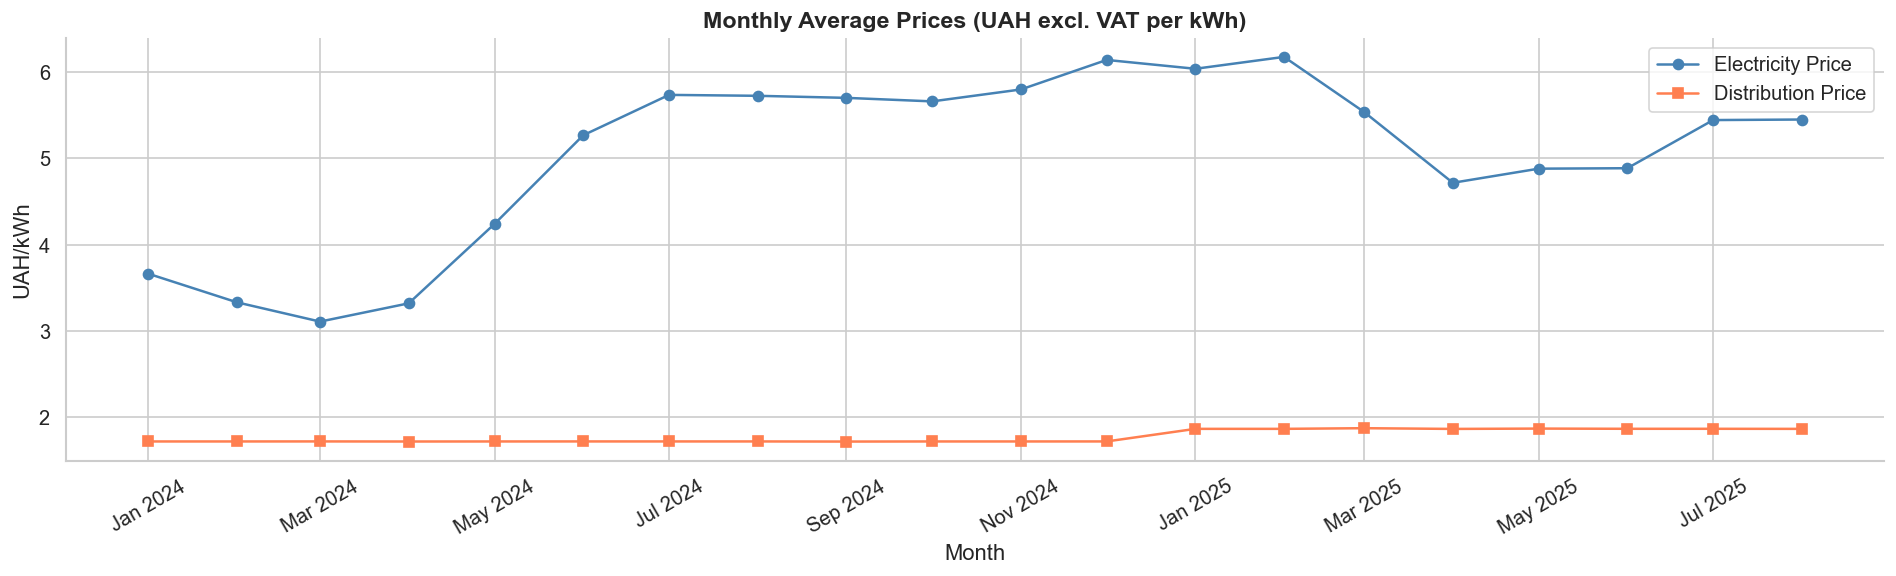

In [73]:
# Monthly average price trends
price_monthly = df.groupby(['Year', 'Month']).agg(
    avg_price = (COL_PRICE, 'mean'),
    avg_dist  = (COL_DIST,  'mean'),
).reset_index()
price_monthly['period'] = pd.to_datetime(
    price_monthly['Year'].astype(str) + '-' + price_monthly['Month'].astype(str).str.zfill(2)
)
price_monthly = price_monthly.sort_values('period')

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(price_monthly['period'], price_monthly['avg_price'], marker='o', label='Electricity Price', color='steelblue')
ax.plot(price_monthly['period'], price_monthly['avg_dist'],  marker='s', label='Distribution Price', color='coral')
ax.set_title('Monthly Average Prices (UAH excl. VAT per kWh)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('UAH/kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

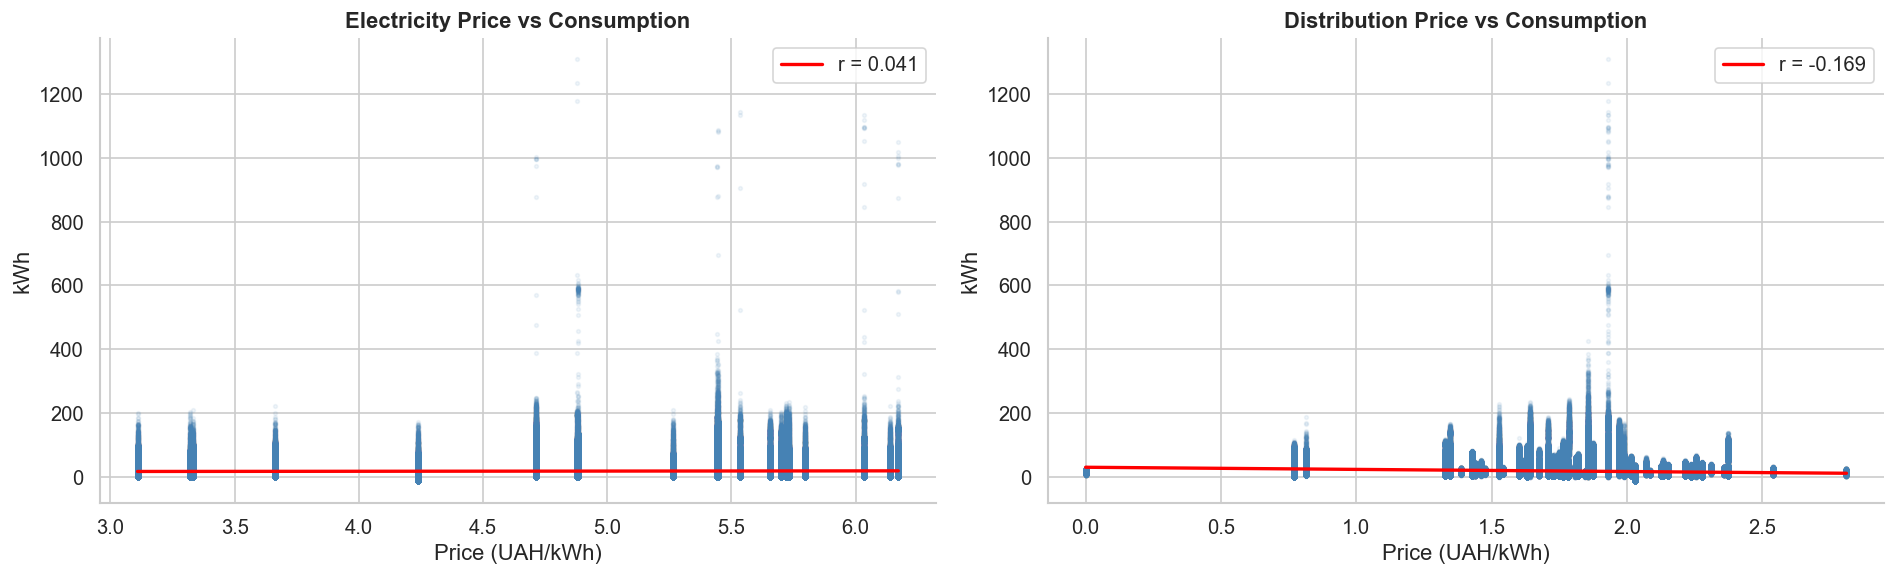

In [74]:
# Price vs Consumption scatter (sampled)
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

for ax, price_col, title in zip(
    axes,
    [COL_PRICE, COL_DIST],
    ['Electricity Price vs Consumption', 'Distribution Price vs Consumption']
):
    data = df_sample[[price_col, COL_KWH]].dropna()
    ax.scatter(data[price_col], data[COL_KWH], alpha=0.08, s=5, color='steelblue')
    # Trend line
    m, b, r, p, _ = stats.linregress(data[price_col], data[COL_KWH])
    x_range = np.linspace(data[price_col].min(), data[price_col].max(), 100)
    ax.plot(x_range, m * x_range + b, color='red', linewidth=2, label=f'r = {r:.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Price (UAH/kWh)')
    ax.set_ylabel('kWh')
    ax.legend()

plt.tight_layout()
plt.show()

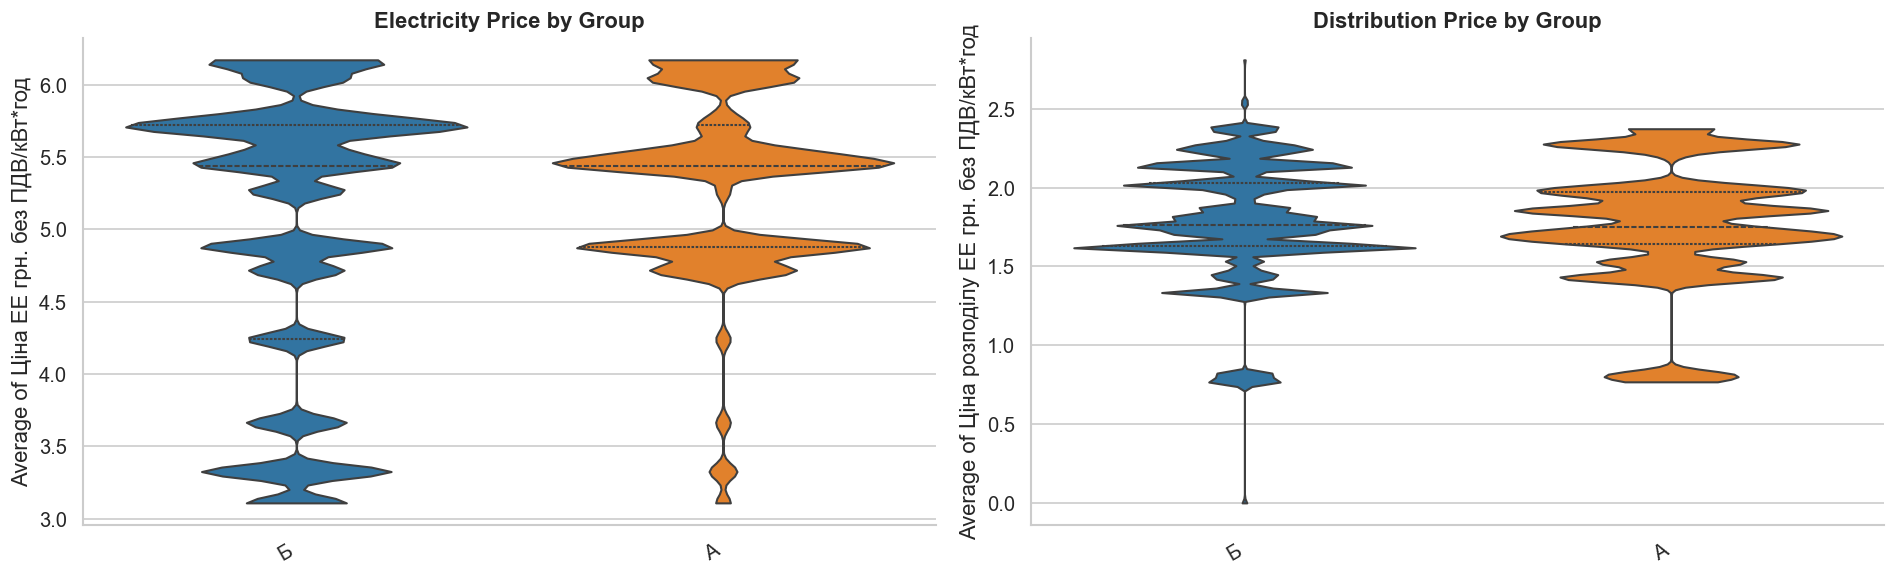

In [75]:
# Price distribution by group (violin)
df_top_grp = df[df[COL_GROUP].isin(top5_groups)]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, col, title in zip(axes, [COL_PRICE, COL_DIST],
                          ['Electricity Price by Group', 'Distribution Price by Group']):
    data_plot = df_top_grp[[COL_GROUP, col]].dropna()
    sns.violinplot(data=data_plot, x=COL_GROUP, y=col, ax=ax, palette='tab10',
                   inner='quartile', cut=0)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 9. Outlier Detection

In [76]:
# IQR-based outlier detection
def iqr_outliers(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (series < q1 - k * iqr) | (series > q3 + k * iqr)
    return mask

for col in num_cols:
    mask = iqr_outliers(df[col].dropna())
    n_out = mask.sum()
    pct   = n_out / len(df[col].dropna()) * 100
    print(f'{col:60s}: {n_out:6,} outliers ({pct:.2f}%)  |  '
          f'Max = {df[col].max():,.2f}  |  '
          f'99.9th pct = {df[col].quantile(0.999):,.2f}')

Sum of кВт                                                  : 192,590 outliers (3.53%)  |  Max = 1,311.50  |  99.9th pct = 143.26
Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год           :  8,783 outliers (0.16%)  |  Max = 2.81  |  99.9th pct = 2.54
Average of Ціна ЕЕ грн. без ПДВ/кВт*год                     :      0 outliers (0.00%)  |  Max = 6.17  |  99.9th pct = 6.17


In [77]:
# Zero-consumption hours
n_zero    = (df[COL_KWH] == 0).sum()
n_neg     = (df[COL_KWH] < 0).sum()
n_missing = df[COL_KWH].isna().sum()

print(f'Zero kWh records   : {n_zero:,}  ({n_zero/len(df)*100:.2f}%)')
print(f'Negative kWh       : {n_neg:,}')
print(f'Missing kWh        : {n_missing:,}')

Zero kWh records   : 630  (0.01%)
Negative kWh       : 744
Missing kWh        : 0


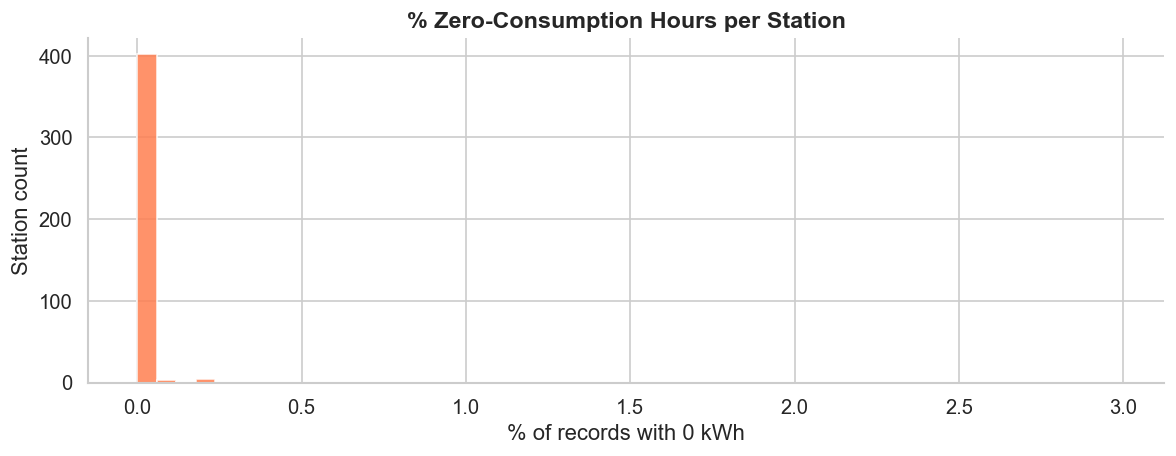

Stations with zero hours: 397
Stations with >0.1% zero hours: 9
Stations with >1% zero hours: 1


In [86]:
# Stations with suspiciously many zero-consumption hours
zero_by_station = (
    df.groupby(COL_EIC)
    .apply(lambda g: (g[COL_KWH] == 0).sum() / len(g) * 100)
    .reset_index(name='pct_zero')
    .sort_values('pct_zero', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(zero_by_station['pct_zero'], bins=50, color='coral', edgecolor='white', alpha=0.85)
ax.set_title('% Zero-Consumption Hours per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('% of records with 0 kWh')
ax.set_ylabel('Station count')
plt.tight_layout()
plt.show()


print(f'Stations with zero hours: {(zero_by_station["pct_zero"] == 0).sum()}')
print(f'Stations with >0.1% zero hours: {(zero_by_station["pct_zero"] > 0.1).sum()}')
print(f'Stations with >1% zero hours: {(zero_by_station["pct_zero"] > 1).sum()}')

## 10. Correlation Analysis

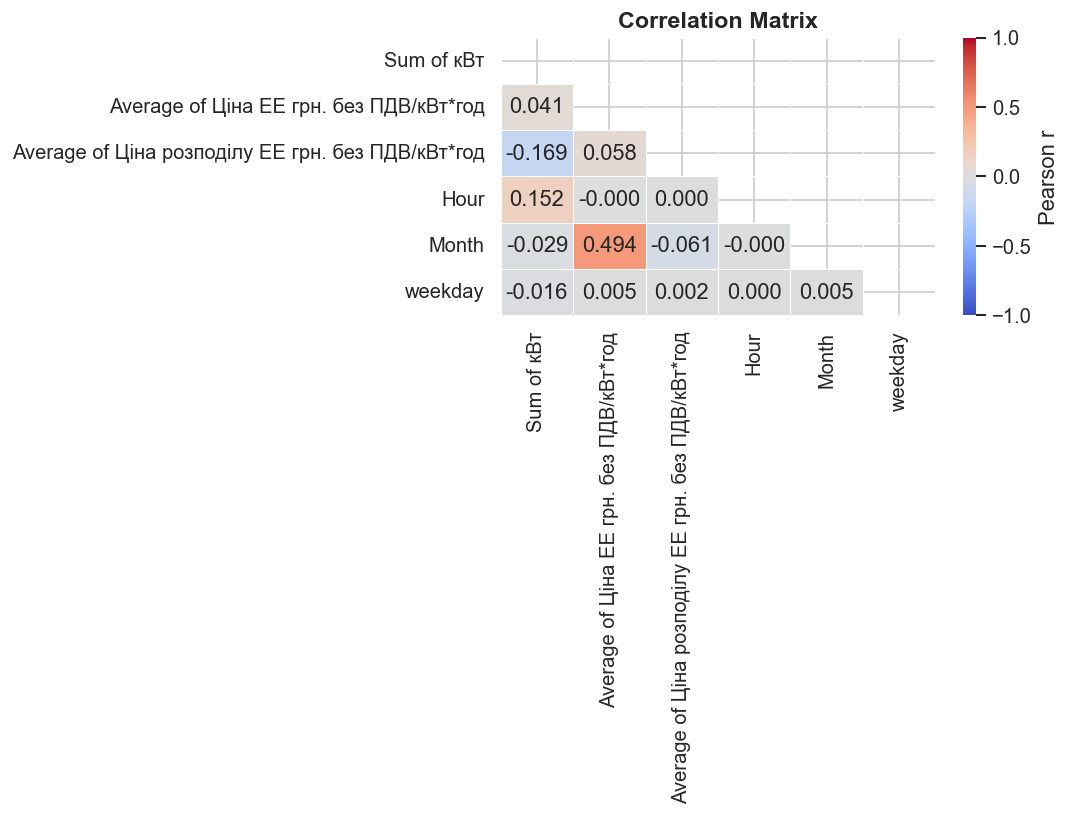

In [79]:
# Correlation matrix
corr_cols = [COL_KWH, COL_PRICE, COL_DIST, 'Hour', 'Month', 'weekday']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Duplicate & Data-Quality Checks

In [80]:
# ── Duplicate hourly records ───────────────────────────────────────────────
dup_key = [COL_EIC, COL_DATE, 'Hour']
n_dups = df.duplicated(subset=dup_key).sum()
print(f'Duplicate (EIC, Date, Hour) records: {n_dups:,}  ({n_dups/len(df)*100:.3f}%)')

Duplicate (EIC, Date, Hour) records: 0  (0.000%)


Expected hours per station : 14,616
Median coverage            : 100.0%
Stations < 80% coverage    : 59
Stations > 100% (dups?)    : 0


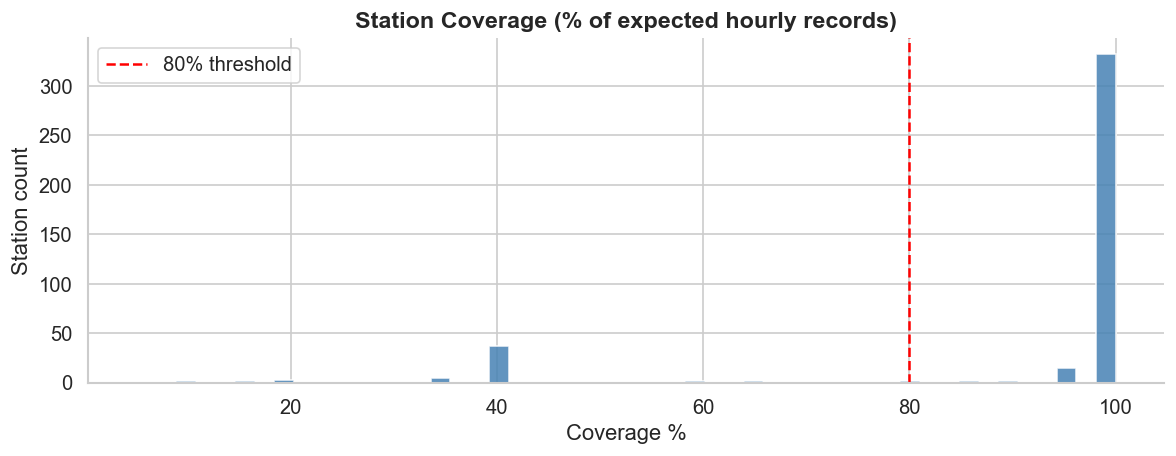

In [81]:
# ── Coverage gaps: missing hours per station ───────────────────────────────
# Expected: n_days_in_range * 24 hours per station
date_min = df[COL_DATE].min()
date_max = df[COL_DATE].max()
expected_hours = int((date_max - date_min).days + 1) * 24

actual_hours = df.groupby(COL_EIC)['Hour'].count()
coverage_pct = (actual_hours / expected_hours * 100).reset_index()
coverage_pct.columns = [COL_EIC, 'coverage_%']

print(f'Expected hours per station : {expected_hours:,}')
print(f'Median coverage            : {coverage_pct["coverage_%"].median():.1f}%')
print(f'Stations < 80% coverage    : {(coverage_pct["coverage_%"] < 80).sum()}')
print(f'Stations > 100% (dups?)    : {(coverage_pct["coverage_%"] > 100).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(coverage_pct['coverage_%'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(80, color='red', linestyle='--', label='80% threshold')
ax.set_title('Station Coverage (% of expected hourly records)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage %')
ax.set_ylabel('Station count')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Summary Statistics Table

In [82]:
summary = pd.DataFrame({
    'Metric': [
        'Total rows',
        'Unique stations (EIC)',
        'Unique groups',
        'Date range (days)',
        'Total kWh',
        'Avg kWh / record',
        'Median kWh / record',
        'Avg electricity price (UAH/kWh)',
        'Avg distribution price (UAH/kWh)',
        'Zero-kWh records (%)',
        'Missing kWh (%)',
    ],
    'Value': [
        f'{len(df):,}',
        f'{df[COL_EIC].nunique():,}',
        f'{df[COL_GROUP].nunique():,}',
        f'{(df[COL_DATE].max() - df[COL_DATE].min()).days:,}',
        f'{df[COL_KWH].sum():,.0f}',
        f'{df[COL_KWH].mean():.3f}',
        f'{df[COL_KWH].median():.3f}',
        f'{df[COL_PRICE].mean():.4f}',
        f'{df[COL_DIST].mean():.4f}',
        f'{(df[COL_KWH] == 0).mean()*100:.2f}%',
        f'{df[COL_KWH].isna().mean()*100:.2f}%',
    ]
})

summary.style.set_properties(**{'text-align': 'left'}) \
             .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,Metric,Value
0,Total rows,"5,454,713"
1,Unique stations (EIC),411
2,Unique groups,2
3,Date range (days),608
4,Total kWh,"93,608,624"
5,Avg kWh / record,17.161
6,Median kWh / record,14.085
7,Avg electricity price (UAH/kWh),5.0535
8,Avg distribution price (UAH/kWh),1.7848
9,Zero-kWh records (%),0.01%


## 13. Export Aggregated Tables

In [83]:
import os
os.makedirs('../data/processed', exist_ok=True)

station_agg.to_csv('data/processed/station_aggregation.csv', index=False)
group_agg.to_csv('data/processed/group_aggregation.csv', index=False)
monthly.to_csv('data/processed/monthly_aggregation.csv', index=False)
summary.to_csv('data/processed/eda_summary.csv', index=False)

print('Exported:')
print('  data/processed/station_aggregation.csv')
print('  data/processed/group_aggregation.csv')
print('  data/processed/monthly_aggregation.csv')
print('  data/processed/eda_summary.csv')

Exported:
  data/processed/station_aggregation.csv
  data/processed/group_aggregation.csv
  data/processed/monthly_aggregation.csv
  data/processed/eda_summary.csv
